# kT-RAM Neural Core — Instruction Comparison Across Device Types

Runs the **same instruction sequence** on all four device types — `float`, `byte`, `mss`,
`rs` — and overlays the normalized activation `y = (Ga-Gb)/(Ga+Gb)` (scale-invariant, so it
is the apples-to-apples metric). Feedback experiments place every type at the **same initial
`y0`** first via `set_start_y`.

**Rate tuning.** MSS and RS saturate much faster than Float at their lesson-reproducing
defaults, so here they run with reduced `pulse_width` (MSS `1e-7`, RS `2e-9`) to bring their
time-to-saturate close to Float's ~1250 steps. This is a per-notebook visualization choice;
the package defaults (which reproduce the lesson) are unchanged. Byte has no time dependence
(`dG = round(dV)`), so it stays fast (~65 steps) and cannot be slowed by `pulse_width`.


In [1]:
%pip install -q ktram-neural-core matplotlib

Note: you may need to restart the kernel to use updated packages.


In [2]:
import matplotlib.pyplot as plt
from ktram_neural_core import Core

TYPES  = ['float', 'byte', 'mss', 'rs']
COLORS = {'float':'tab:blue', 'byte':'tab:orange', 'mss':'tab:green', 'rs':'tab:red'}
Z = (0,)

# Reduced pulse_width so MSS/RS saturate on a Float-like timescale (visualization only;
# package defaults reproduce the lesson). Edit these to taste.
TUNED = {'mss': {'pulse_width': 1e-7}, 'rs': {'pulse_width': 2e-9}}

def run_phases(model, phases, init='medium', start_y=None, seed=1):
    """phases = list of (read, feedback_or_None, n). Returns (ys, gas, gbs)."""
    core = Core(1, 1, model=model, init=init, seed=seed, **TUNED.get(model, {}))
    lane = core.lane(0)
    if start_y is not None:
        core.set_start_y(0, Z, start_y)
    ys, gas, gbs = [], [], []
    for read, fb, n in phases:
        for _ in range(n):
            y = lane.evaluate(Z, read)
            if fb is not None:
                lane.evaluate(Z, fb)
            ga, gb = core.read_gab(0, Z)
            ys.append(y); gas.append(ga); gbs.append(gb)
    return ys, gas, gbs

def run_all(phases, **kw):
    return {m: run_phases(m, phases, **kw) for m in TYPES}

def compare_y(results, title, ax=None):
    if ax is None:
        _, ax = plt.subplots(figsize=(8.5, 3.6))
    for m in TYPES:
        ax.plot(results[m][0], color=COLORS[m], lw=1.3, label=m)
    ax.set_ylim(-1.05, 1.05); ax.axhline(0, color='0.85', lw=0.8)
    ax.grid(True, color='0.92'); ax.set_title(title)
    ax.set_xlabel('step'); ax.set_ylabel('y'); ax.legend(loc='best')
    return ax

def grid_conductance(results, title):
    fig, axes = plt.subplots(1, 4, figsize=(15, 2.9))
    for ax, m in zip(axes, TYPES):
        _, gas, gbs = results[m]
        ax.plot(gas, label='Ga', color='tab:blue'); ax.plot(gbs, label='Gb', color='tab:green')
        ax.margins(y=0.12); ax.set_title(m); ax.grid(True, color='0.93'); ax.legend(fontsize=8)
    fig.suptitle(title); fig.tight_layout(); return fig

## 1. Pulse up / down  —  `(FF, RH)xN` then `(FF, RL)xN`  (init MEDIUM)
Float sweeps to ±1, Byte plateaus at ±0.5 (rounding ceiling, fast), MSS is stochastic, RS is float-like.


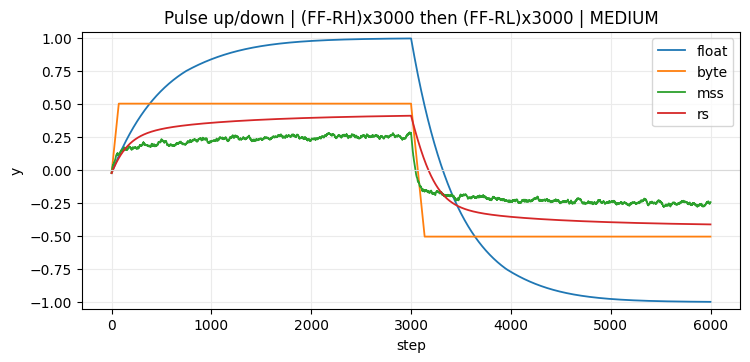

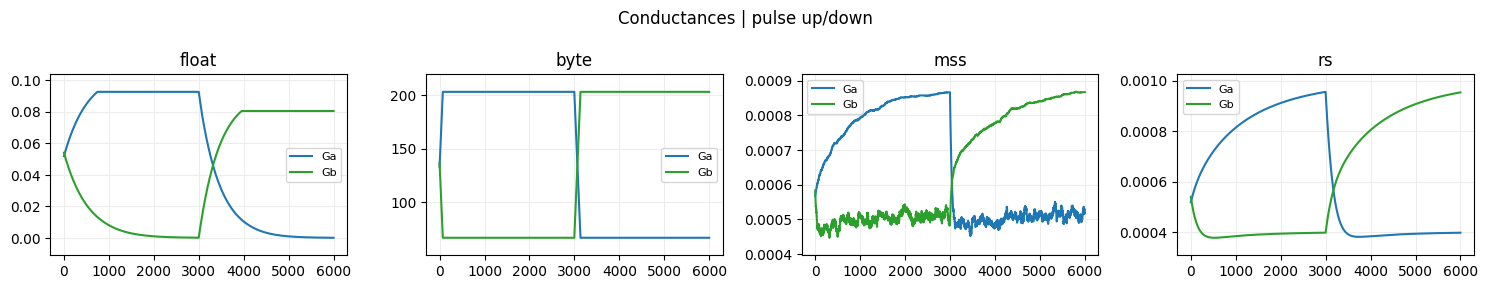

In [3]:
res = run_all([('FF','RH',3000), ('FF','RL',3000)], init='medium')
compare_y(res, 'Pulse up/down | (FF-RH)x3000 then (FF-RL)x3000 | MEDIUM'); plt.show()
grid_conductance(res, 'Conductances | pulse up/down'); plt.show()

## 2. Drive up vs drive down  —  `FF-RH` / `FF-RL` from matched opposite starts
RH drives every type up from `y0=-0.5`; RL drives every type down from `y0=+0.5`.


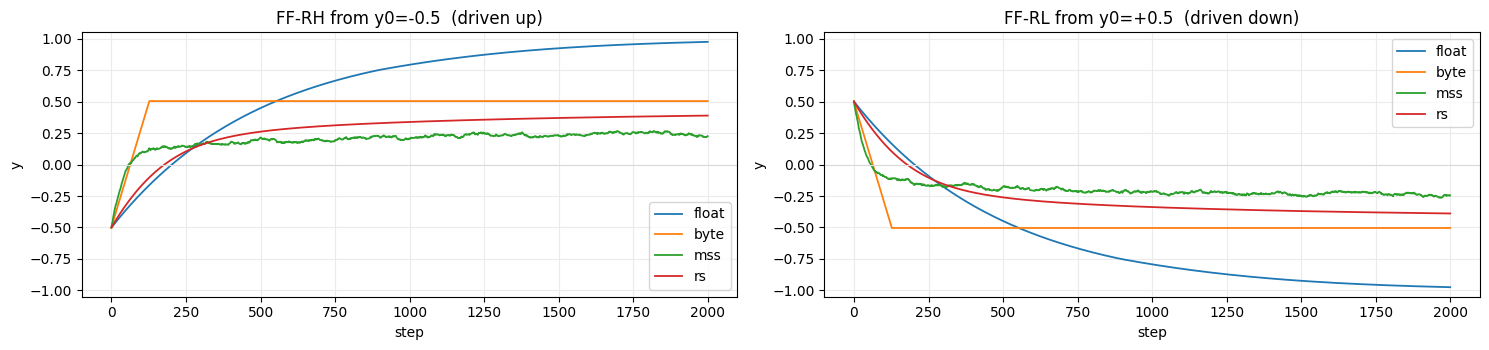

In [4]:
up = run_all([('FF','RH',2000)], start_y=-0.5)
dn = run_all([('FF','RL',2000)], start_y=+0.5)
fig, ax = plt.subplots(1, 2, figsize=(15, 3.6))
compare_y(up, 'FF-RH from y0=-0.5  (driven up)', ax[0])
compare_y(dn, 'FF-RL from y0=+0.5  (driven down)', ax[1])
plt.tight_layout(); plt.show()

## 3. Hebbian vs anti-Hebbian  —  `FF-RU` / `FF-RA`, same initial condition `y0=+0.4`
RU reinforces the sign (-> +1); RA erodes it (-> 0).


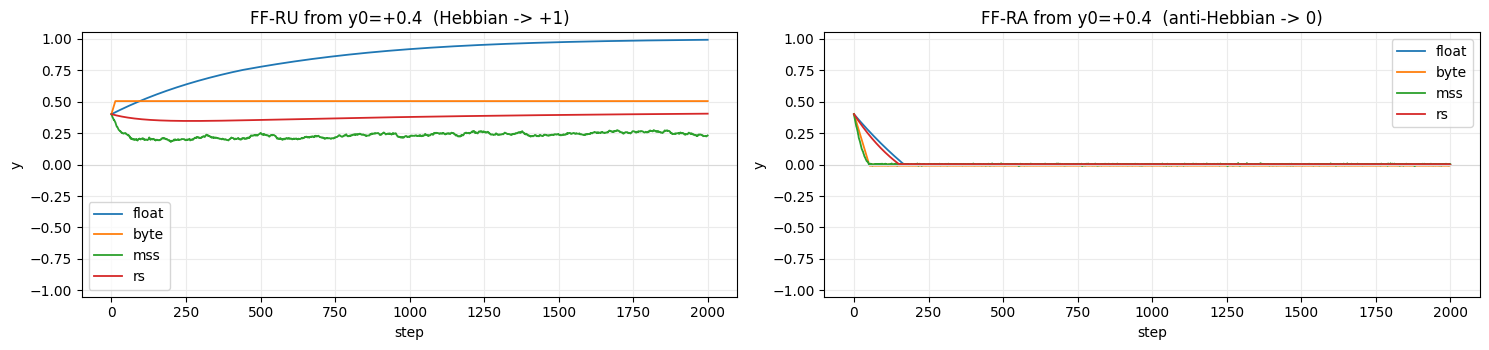

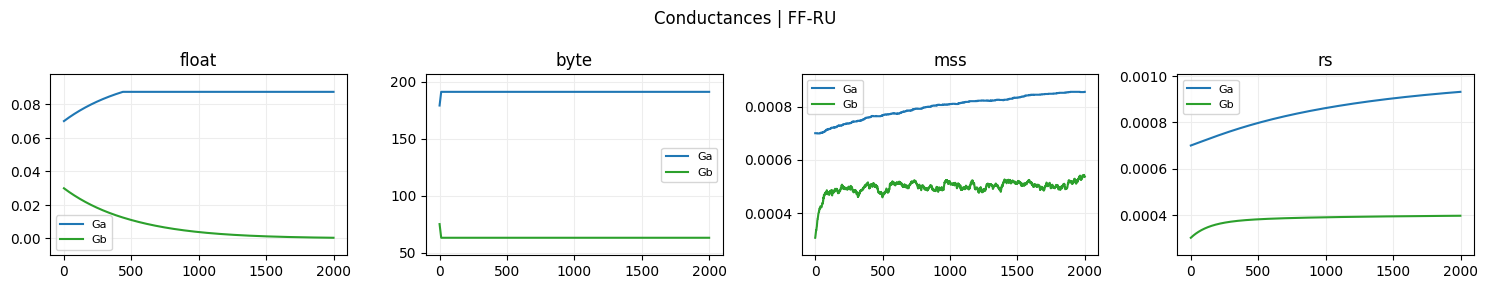

In [5]:
ru = run_all([('FF','RU',2000)], start_y=0.4)
ra = run_all([('FF','RA',2000)], start_y=0.4)
fig, ax = plt.subplots(1, 2, figsize=(15, 3.6))
compare_y(ru, 'FF-RU from y0=+0.4  (Hebbian -> +1)', ax[0])
compare_y(ra, 'FF-RA from y0=+0.4  (anti-Hebbian -> 0)', ax[1])
plt.tight_layout(); plt.show()
grid_conductance(ru, 'Conductances | FF-RU'); plt.show()

## 4. Decay  —  `FF-RZ`, `y0=+0.6`
RZ has no state-directed effect, so the anti-Hebbian FF read pulls every type toward zero.


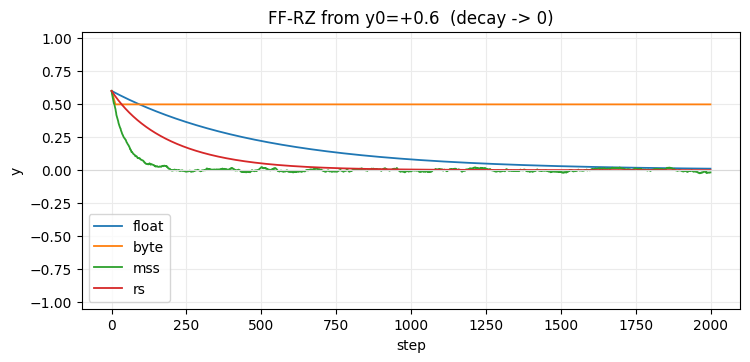

In [6]:
rz = run_all([('FF','RZ',2000)], start_y=0.6)
compare_y(rz, 'FF-RZ from y0=+0.6  (decay -> 0)'); plt.show()

## 5. Read direction sets plasticity  —  `FF-XX` vs `RF-XX`, `y0=+0.3`
FF is anti-Hebbian (-> 0); RF is Hebbian (-> +/-1). The reverse read flips the plasticity sign.


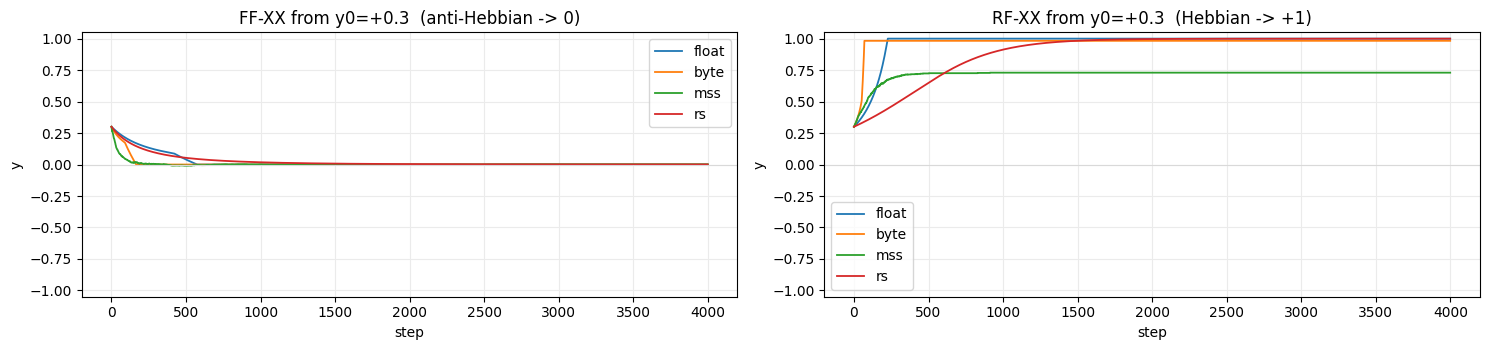

In [7]:
ff = run_all([('FF', None, 4000)], start_y=0.3)
rf = run_all([('RF', None, 4000)], start_y=0.3)
fig, ax = plt.subplots(1, 2, figsize=(15, 3.6))
compare_y(ff, 'FF-XX from y0=+0.3  (anti-Hebbian -> 0)', ax[0])
compare_y(rf, 'RF-XX from y0=+0.3  (Hebbian -> +1)', ax[1])
plt.tight_layout(); plt.show()

## 6. Low-voltage reads  —  `FFLV` / `RFLV`, `y0=+0.5`
Sub-threshold: Float/Byte sit still (dead-zone / round-to-0); MSS/RS drift only slightly.


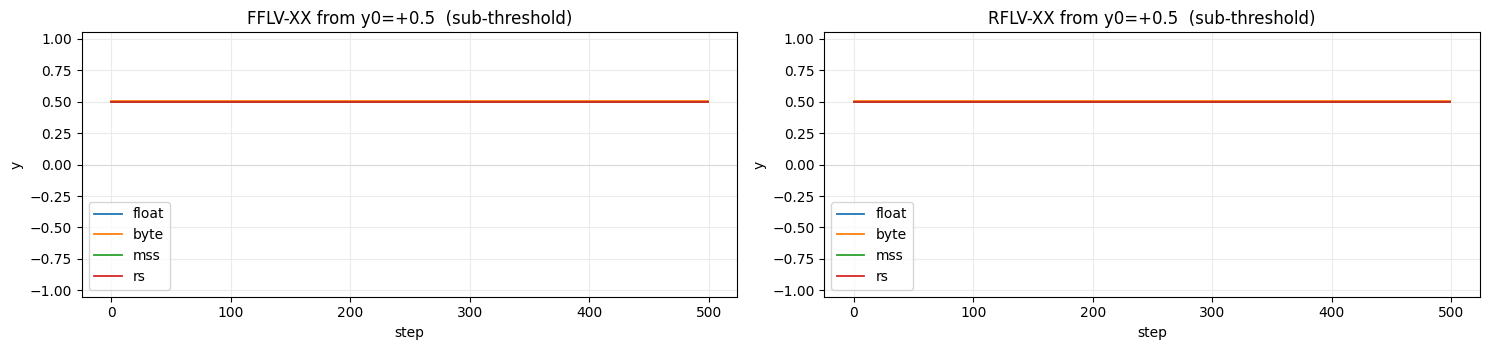

In [8]:
fflv = run_all([('FFLV', None, 500)], start_y=0.5)
rflv = run_all([('RFLV', None, 500)], start_y=0.5)
fig, ax = plt.subplots(1, 2, figsize=(15, 3.6))
compare_y(fflv, 'FFLV-XX from y0=+0.5  (sub-threshold)', ax[0])
compare_y(rflv, 'RFLV-XX from y0=+0.5  (sub-threshold)', ax[1])
plt.tight_layout(); plt.show()

## 7. MSS RNG demo (MSS only)
`(FF, RA)x500` then `(FF, RZ)x500` on `MEDIUM_NOISE` — oscillates about zero; digitized final read is a fair bit.


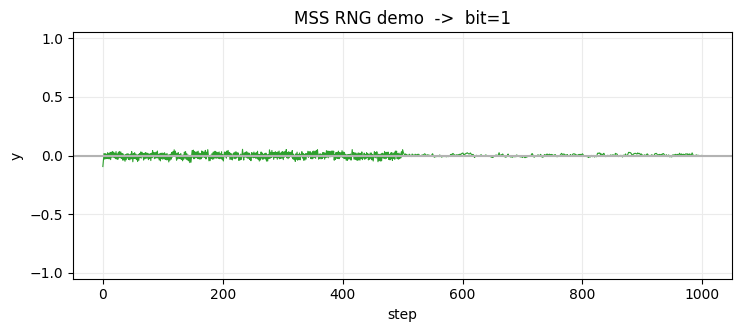

In [9]:
core = Core(1, 1, model='mss', init='medium_noise', seed=6); lane = core.lane(0)
ys = []
for read, fb, n in [('FF','RA',500), ('FF','RZ',500)]:
    for _ in range(n):
        ys.append(lane.evaluate(Z, read)); lane.evaluate(Z, fb)
bit = 1 if ys[-1] > 0 else 0
plt.figure(figsize=(8.5, 3.2)); plt.plot(ys, color='tab:green', lw=0.8)
plt.axhline(0, color='0.7'); plt.ylim(-1.05, 1.05); plt.grid(True, color='0.92')
plt.title(f'MSS RNG demo  ->  bit={bit}'); plt.xlabel('step'); plt.ylabel('y'); plt.show()